# Notebook 2 - Contaminantes CDMX 2026 (SIMAT/RAMA)

Datos horarios de 1-ene-2026 a 28-feb-2026. Contenido:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

RUTA = "contaminantes_2026.csv"

## a) Tabla con un renglón por estación-hora y una columna por contaminante

El archivo trae 9 líneas de metadatos antes del encabezado real (`skiprows=9`) y está en formato largo
(`date, id_station, id_parameter, valor`). Con `pivot` pasamos a formato ancho. Usamos `pivot` y no
`pivot_table` para **conservar** las combinaciones estación-hora donde todo es faltante (así hay exactamente 34 estaciones × 1416 horas).

In [4]:
largo = pd.read_csv(RUTA, skiprows=9)
largo["valor"] = pd.to_numeric(largo["valor"], errors="coerce")
largo["date"] = pd.to_datetime(largo["date"])

print("Duplicados (date, estación, parámetro):", largo.duplicated(["date", "id_station", "id_parameter"]).sum())

tabla = largo.pivot(index=["date", "id_station"], columns="id_parameter", values="valor")
tabla.columns.name = None
CONTAM = list(tabla.columns)

print("Forma:", tabla.shape, "| estaciones:", tabla.index.get_level_values(1).nunique(),
      "| horas:", tabla.index.get_level_values(0).nunique())
print("Contaminantes:", CONTAM)
tabla.head(10)

Duplicados (date, estación, parámetro): 0
Forma: (48144, 9) | estaciones: 34 | horas: 1416
Contaminantes: ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PMCO', 'SO2']


CO   NO   NO2   NOX    O3  PM10  PM2.5  PMCO   SO2
date       id_station                                                      
2026-01-01 ACO          NaN  NaN   NaN   NaN   NaN   NaN    NaN   NaN   NaN
           AJM         0.84  2.0  26.0  28.0  19.0  67.0   53.0  14.0  28.0
           AJU          NaN  NaN   NaN   NaN   NaN   NaN    NaN   NaN   NaN
           ATI         0.80  2.0  21.0  23.0  18.0  90.0    NaN   NaN  22.0
           BJU         1.22  NaN   NaN   NaN  17.0  62.0   41.0  21.0   NaN
           CAM          NaN  7.0  44.0  52.0   4.0  57.0   49.0   8.0  25.0
           CCA         1.27  1.0  32.0  33.0  14.0   NaN    NaN   NaN   3.0
           CHO          NaN  NaN   NaN   NaN   NaN   NaN    NaN   NaN   NaN
           CUA          NaN  3.0  28.0  31.0  22.0   NaN    NaN   NaN  28.0
           CUT         0.80  2.0  29.0  31.0   9.0   0.0    NaN   NaN  12.0

In [5]:
faltantes = pd.DataFrame({"% faltante": tabla.isna().mean() * 100, "n válidos": tabla.notna().sum()})
print(faltantes.round(1))
print("\nRenglones con los 9 contaminantes:", tabla.dropna().shape[0], "de", len(tabla))
print("Renglones completamente vacíos:", tabla.isna().all(axis=1).sum())

       % faltante  n válidos
CO           43.9      27013
NO           48.5      24796
NO2          44.1      26908
NOX          48.6      24759
O3           33.0      32242
PM10         59.6      19468
PM2.5        69.0      14908
PMCO         79.3       9956
SO2          41.3      28273

Renglones con los 9 contaminantes: 5809 de 48144
Renglones completamente vacíos: 14162


## b) Covarianza y correlación de CO con NOX

Con faltantes se usa **eliminación por pares** (pairwise): cada estadístico usa los renglones donde ambas variables están presentes.

In [6]:
par = tabla[["CO", "NOX"]].dropna()
n_par = len(par)

cov_co_nox = par["CO"].cov(par["NOX"])
corr_co_nox = par["CO"].corr(par["NOX"])
sd_co, sd_nox = par["CO"].std(), par["NOX"].std()

print(f"n (pares completos)  = {n_par}")
print(f"Cov(CO, NOX)         = {cov_co_nox:.4f}   [unidades: CO × NOX]")
print(f"Corr(CO, NOX)        = {corr_co_nox:.4f}   [adimensional, en [-1, 1]]")
print(f"Cov / (sd_CO·sd_NOX) = {cov_co_nox / (sd_co * sd_nox):.4f}   <- reproduce la correlación")
print()
print("Matriz de covarianza:"); display(par.cov())
print("Matriz de correlación:"); display(par.corr())

n (pares completos)  = 22332
Cov(CO, NOX)         = 22.3069   [unidades: CO × NOX]
Corr(CO, NOX)        = 0.8568   [adimensional, en [-1, 1]]
Cov / (sd_CO·sd_NOX) = 0.8568   <- reproduce la correlación

Matriz de covarianza:


,CO,NOX
CO,0.2991,22.3069
NOX,22.3069,2266.7797


Matriz de correlación:


,CO,NOX
CO,1.0000,0.8568
NOX,0.8568,1.0000


Cov(1000·CO, NOX)  = 22306.91   (se multiplicó por 1000)
Corr(1000·CO, NOX) = 0.8568   (idéntica)
Cov de las variables estandarizadas = 0.8568  (= correlación)


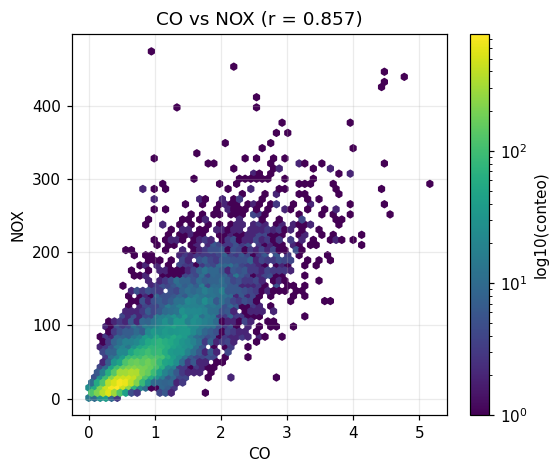

In [7]:
# ¿Cambian con las unidades? Covarianza sí, correlación no.
co_x1000 = par["CO"] * 1000   # p. ej. de ppm a ppb
print(f"Cov(1000·CO, NOX)  = {co_x1000.cov(par['NOX']):.2f}   (se multiplicó por 1000)")
print(f"Corr(1000·CO, NOX) = {co_x1000.corr(par['NOX']):.4f}   (idéntica)")

z = (par - par.mean()) / par.std()
print(f"Cov de las variables estandarizadas = {z['CO'].cov(z['NOX']):.4f}  (= correlación)")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
hb = ax.hexbin(par["CO"], par["NOX"], gridsize=60, bins="log", cmap="viridis", mincnt=1)
ax.set(xlabel="CO", ylabel="NOX", title=f"CO vs NOX (r = {corr_co_nox:.3f})")
fig.colorbar(hb, label="log10(conteo)")
plt.show()

**¿Son distintas?** Sí, miden cosas diferentes aunque cuenten la misma historia:

- La **covarianza** (valor mostrado arriba) está en unidades de CO × NOX; su magnitud depende de la escala de medición
  (al reescalar CO ×1000 la covarianza se multiplica ×1000) y por sí sola no dice qué tan fuerte es la relación.
- La **correlación** es la covarianza dividida entre las dos desviaciones estándar: no tiene unidades, es invariante a cambios de escala y siempre está en [-1, 1].
  Aquí es alta y positiva, consistente con que CO y NOX provienen principalmente de la combustión vehicular.

Ambas tienen el mismo signo, pero solo la correlación es interpretable directamente como intensidad de la asociación lineal.

## c) Eigenvalores de la matriz de correlación, con y sin faltantes

- **Con faltantes**: correlación por pares (cada entrada usa todos los datos disponibles para ese par).
  Al usar subconjuntos distintos por entrada, la matriz **puede dejar de ser positiva semidefinida** (eigenvalores negativos).
- **Sin faltantes**: solo renglones completos (listwise). Siempre es PSD y los eigenvalores suman p.

In [8]:
p = len(CONTAM)

R_pares = tabla.corr()                      # pairwise
completos = tabla.dropna()
R_comp = completos.corr()                   # listwise

def eigs(R):
    w, V = np.linalg.eigh(R.values)
    idx = np.argsort(w)[::-1]
    return w[idx], V[:, idx]

w_par, V_par = eigs(R_pares)
w_comp, V_comp = eigs(R_comp)

res = pd.DataFrame({
    "λ con faltantes (pares)": w_par,
    "λ sin faltantes (completos)": w_comp,
}, index=[f"λ{i+1}" for i in range(p)])
res["% var. (completos)"] = 100 * w_comp / p
res["% acum. (completos)"] = res["% var. (completos)"].cumsum()
display(res)

print(f"n con pares: {tabla.notna().sum().min()}–{tabla.notna().sum().max()} por variable | n completos: {len(completos)}")
print(f"Suma de eigenvalores  pares = {w_par.sum():.4f} | completos = {w_comp.sum():.4f} | p = {p}")
print(f"Mínimo eigenvalor     pares = {w_par.min():.5f} | completos = {w_comp.min():.5f}")
print("¿Matriz por pares PSD?", bool(w_par.min() >= -1e-12))
print(f"Número de condición (λmax/λmin) completos = {w_comp.max()/w_comp.min():.0f}  -> muy mal condicionada (colinealidad)")

,λ con faltantes (pares),λ sin faltantes (completos),% var. (completos),% acum. (completos)
λ1,4.1447,4.1880e+00,46.5336,46.5336
λ2,1.9214,1.9399e+00,21.5550,68.0885
λ3,1.0301,1.0494e+00,11.6601,79.7486
λ4,0.7494,8.0615e-01,8.9573,88.7059
λ5,0.5357,5.1999e-01,5.7777,94.4836
λ6,0.4719,3.7175e-01,4.1305,98.6141
λ7,0.1552,1.2438e-01,1.3820,99.9961
λ8,0.0003,2.8227e-04,0.0031,99.9992
λ9,-0.0087,6.9279e-05,0.0008,100.0000


n con pares: 9956–32242 por variable | n completos: 5809
Suma de eigenvalores  pares = 9.0000 | completos = 9.0000 | p = 9
Mínimo eigenvalor     pares = -0.00868 | completos = 0.00007
¿Matriz por pares PSD? False
Número de condición (λmax/λmin) completos = 60451  -> muy mal condicionada (colinealidad)


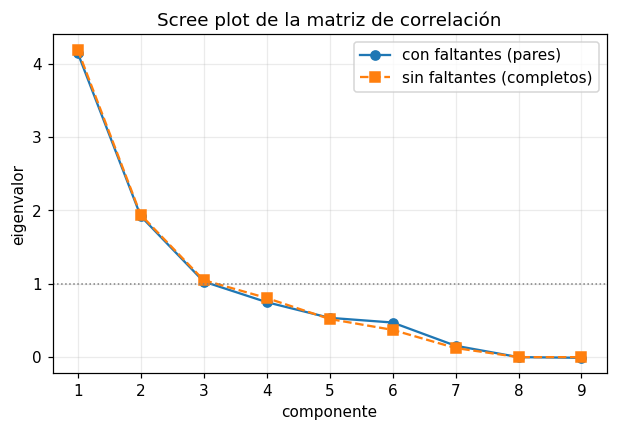

Cargas del 1er eigenvector (completos):
CO      -0.435
NO      -0.381
NO2     -0.419
NOX     -0.443
O3       0.190
PM10    -0.329
PM2.5   -0.261
PMCO    -0.272
SO2     -0.082


In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
k = np.arange(1, p + 1)
ax.plot(k, w_par, "o-", label="con faltantes (pares)")
ax.plot(k, w_comp, "s--", label="sin faltantes (completos)")
ax.axhline(1, color="gray", lw=1, ls=":")
ax.set(xlabel="componente", ylabel="eigenvalor", title="Scree plot de la matriz de correlación", xticks=k)
ax.legend()
plt.show()

print("Cargas del 1er eigenvector (completos):")
print(pd.Series(V_comp[:, 0], index=CONTAM).round(3).to_string())

**Lectura.** Los eigenvalores suman p = 9 en ambos casos si la matriz es válida, pero su reparto cambia: los faltantes no son aleatorios
(PM2.5 y PMCO se miden en pocas estaciones), así que la matriz por pares y la de casos completos describen subpoblaciones distintas.
Eigenvalores cercanos a 0 indican colinealidad: aquí aparece por NOX ≈ NO + NO2 y PM10 ≈ PM2.5 + PMCO.

## d) PM2.5 contra los demás: R² y VIF

Se ajusta OLS con intercepto. R² = 1 − SCE/SCT. El **VIF** de cada predictor se obtiene de la diagonal de la inversa de la matriz de correlación
de los predictores: VIF_j = [R⁻¹]_jj (equivale a 1/(1−R²_j) de regresar el predictor j contra el resto).

Primero con **todos** los demás contaminantes y luego **solo con gases** (CO, NO, NO2, NOX, O3, SO2), cada uno con sus casos completos.

In [10]:
def ols(X, y):
    """OLS con intercepto vía mínimos cuadrados (lstsq). Devuelve dict con resultados."""
    Xd = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    fit = Xd @ beta
    e = y - fit
    n, k = Xd.shape
    sce = e @ e
    sct = ((y - y.mean()) ** 2).sum()
    return dict(X=Xd, y=y, beta=beta, fit=fit, e=e, n=n, p=k,
                s2=sce / (n - k), r2=1 - sce / sct, r2_adj=1 - (sce / (n - k)) / (sct / (n - 1)))

def vif(Xdf):
    R = np.corrcoef(Xdf.values, rowvar=False)
    return pd.Series(np.diag(np.linalg.inv(R)), index=Xdf.columns)

def ajusta(y_col, x_cols):
    d = tabla[[y_col] + x_cols].dropna()
    m = ols(d[x_cols].values, d[y_col].values)
    m["cols"] = x_cols
    m["data"] = d
    m["vif"] = vif(d[x_cols])
    return m

GASES = ["CO", "NO", "NO2", "NOX", "O3", "SO2"]
OTROS = [c for c in CONTAM if c != "PM2.5"]

m_todos = ajusta("PM2.5", OTROS)
m_gases = ajusta("PM2.5", GASES)

for nombre, m in [("PM2.5 ~ todos los demás", m_todos), ("PM2.5 ~ solo gases", m_gases)]:
    print(f"{nombre}:  n = {m['n']},  R² = {m['r2']:.4f},  R² ajustado = {m['r2_adj']:.4f}")

display(pd.DataFrame({"VIF (todos)": m_todos["vif"], "VIF (solo gases)": m_gases["vif"]}).round(2))

PM2.5 ~ todos los demás:  n = 5809,  R² = 0.9988,  R² ajustado = 0.9988
PM2.5 ~ solo gases:  n = 9247,  R² = 0.2665,  R² ajustado = 0.2661


,VIF (todos),VIF (solo gases)
CO,5.54,4.22
NO,5023.55,5172.82
NO2,1041.72,935.34
NOX,8372.82,8181.52
O3,1.59,1.33
PM10,3.81,NaN
PMCO,3.07,NaN
SO2,1.09,1.03


In [11]:
coefs = pd.DataFrame({"β (todos)": pd.Series(m_todos["beta"], index=["Intercepto"] + OTROS),
                      "β (solo gases)": pd.Series(m_gases["beta"], index=["Intercepto"] + GASES)})
display(coefs.round(4))

# Verificación de las identidades de colinealidad
c = tabla.dropna()
print("NOX − (NO + NO2):       media %.3f, sd %.3f" % ((c.NOX - c.NO - c.NO2).mean(), (c.NOX - c.NO - c.NO2).std()))
print("PM10 − (PM2.5 + PMCO):  media %.3f, sd %.3f" % ((c.PM10 - c['PM2.5'] - c.PMCO).mean(), (c.PM10 - c['PM2.5'] - c.PMCO).std()))

,β (todos),β (solo gases)
CO,-0.0585,13.2980
Intercepto,0.0962,1.2363
NO,-0.0084,-0.5073
NO2,-0.0084,-0.1988
NOX,0.0091,0.4554
O3,-0.0001,0.1741
PM10,0.9981,NaN
PMCO,-0.9990,NaN
SO2,0.0023,0.2124


NOX − (NO + NO2):       media 0.010, sd 0.509
PM10 − (PM2.5 + PMCO):  media -0.038, sd 0.553


**Lectura.**

- Con todos los predictores, R² es casi 1 y los VIF de PM10 y PMCO son enormes: PM10 ≈ PM2.5 + PMCO por definición, así que el modelo
  "predice" PM2.5 casi de forma tautológica (PM2.5 ≈ PM10 − PMCO). No es un hallazgo, es una identidad.
- Con **solo gases**, R² baja mucho: los gases explican poco de la variación de PM2.5.
  Además persiste colinealidad entre NO, NO2 y NOX (NOX ≈ NO + NO2): VIF muy altos en esas tres, aunque el R² global no se ve afectado por ello;
  lo que se degradan son la estabilidad y la interpretación de los coeficientes individuales.

## e) Matriz sombrero H en una estación y una semana

H = X (XᵀX)⁻¹ Xᵀ proyecta y sobre el espacio columna de X (ŷ = H y). Debe cumplir:

- **H² = H** (idempotente, es una proyección)
- **tr(H) = p** (número de columnas de X, incluido el intercepto)

Se usa el modelo PM2.5 ~ gases (p = 7). Se elige automáticamente la estación-semana con más horas completas (n ≈ 168 como máximo).
Luego se calcula el **leverage h_ii de todas las observaciones sin construir H** (que sería de n×n, aquí ≈ 9 000 × 9 000).

In [12]:
d = m_gases["data"].reset_index()
d["semana"] = d["date"].dt.isocalendar().week.astype(int)
conteo = d.groupby(["id_station", "semana"]).size().sort_values(ascending=False)
est, sem = conteo.index[0]
print(f"Estación-semana elegida: {est}, semana ISO {sem}  (n = {conteo.iloc[0]} horas completas)")

sub = d[(d.id_station == est) & (d.semana == sem)]
Xs = np.column_stack([np.ones(len(sub)), sub[GASES].values])
ys = sub["PM2.5"].values

H = Xs @ np.linalg.inv(Xs.T @ Xs) @ Xs.T          # aquí SÍ se construye H (n pequeño)
print(f"X: {Xs.shape} | H: {H.shape}")
print(f"max|H² − H|      = {np.abs(H @ H - H).max():.2e}   -> H² = H: {np.allclose(H @ H, H, atol=1e-6)}")
print(f"traza(H)         = {np.trace(H):.6f}   (p = {Xs.shape[1]})")
print(f"max|H − Hᵀ|      = {np.abs(H - H.T).max():.2e}   -> simétrica")
print(f"ŷ = H y coincide con el ajuste OLS: {np.allclose(H @ ys, Xs @ np.linalg.lstsq(Xs, ys, rcond=None)[0], atol=1e-6)}")
print(f"Rango de leverage en la semana: [{np.diag(H).min():.4f}, {np.diag(H).max():.4f}]  (promedio p/n = {Xs.shape[1]/len(Xs):.4f})")

Estación-semana elegida: UIZ, semana ISO 4  (n = 164 horas completas)
X: (164, 7) | H: (164, 164)
max|H² − H|      = 1.66e-13   -> H² = H: True
traza(H)         = 7.000000   (p = 7)
max|H − Hᵀ|      = 2.48e-13   -> simétrica
ŷ = H y coincide con el ajuste OLS: True
Rango de leverage en la semana: [0.0088, 0.2417]  (promedio p/n = 0.0427)


### Leverage de todas las observaciones sin construir H

Con la descomposición QR, X = QR, se cumple H = QQᵀ, por lo tanto **h_ii = Σ_j Q_ij²** (suma por renglón de Q al cuadrado): O(n·p²) en tiempo y O(n·p) en memoria.

In [13]:
def leverage(X):
    Q, _ = np.linalg.qr(X, mode="reduced")
    return (Q ** 2).sum(axis=1)

# 1) Validación en la estación-semana: coincide con diag(H)
h_sub = leverage(Xs)
print("QR vs diag(H) en la semana:", np.allclose(h_sub, np.diag(H)))

# 2) Todos los datos (n × p), sin H
X_all = m_gases["X"]
h_all = leverage(X_all)
print(f"n = {len(h_all)}, p = {X_all.shape[1]}")
print(f"Σ h_ii = {h_all.sum():.6f}  (debe ser p = {X_all.shape[1]})")
print(f"Memoria evitada: H sería {len(h_all)}² × 8 B ≈ {len(h_all)**2 * 8 / 1e9:.2f} GB")

# 3) Segunda forma equivalente: h_i = x_iᵀ (XᵀX)⁻¹ x_i
h_alt = np.einsum("ij,jk,ik->i", X_all, np.linalg.inv(X_all.T @ X_all), X_all)
print("QR vs fórmula x(XᵀX)⁻¹xᵀ:", np.allclose(h_all, h_alt, atol=1e-8))
print(f"Umbral habitual 2p/n = {2*X_all.shape[1]/len(h_all):.4f} -> obs. con alto leverage: {(h_all > 2*X_all.shape[1]/len(h_all)).sum()}")

QR vs diag(H) en la semana: True
n = 9247, p = 7
Σ h_ii = 7.000000  (debe ser p = 7)
Memoria evitada: H sería 9247² × 8 B ≈ 0.68 GB
QR vs fórmula x(XᵀX)⁻¹xᵀ: True
Umbral habitual 2p/n = 0.0015 -> obs. con alto leverage: 700


## f) Distancia de Cook: ¿los 10 más influyentes son los de más leverage?

$$D_i = \frac{e_i^2}{p\,s^2}\cdot\frac{h_{ii}}{(1-h_{ii})^2}$$

Cook combina **leverage** (qué tan atípico es x_i) con el **residuo** (qué tan mal ajusta y_i). Un punto con leverage alto pero residuo pequeño puede ser poco influyente.

In [14]:
e, s2, p_ = m_gases["e"], m_gases["s2"], m_gases["p"]
cook = (e ** 2 / (p_ * s2)) * h_all / (1 - h_all) ** 2

info = m_gases["data"].reset_index()[["date", "id_station", "PM2.5"] + GASES].copy()
info["leverage"], info["residuo"], info["cook"] = h_all, e, cook

top_cook = info.nlargest(10, "cook")
top_lev = info.nlargest(10, "leverage")

print("TOP 10 por distancia de Cook"); display(top_cook.round({"leverage":4,"residuo":2,"cook":4}))
print("TOP 10 por leverage");          display(top_lev.round({"leverage":4,"residuo":2,"cook":4}))

inter = set(top_cook.index) & set(top_lev.index)
print(f"Coincidencias entre ambos top-10: {len(inter)} de 10")

TOP 10 por distancia de Cook


,date,id_station,PM2.5,CO,NO,NO2,NOX,O3,SO2,leverage,residuo,cook
55,2026-01-01 07:00:00,SAC,323.0,2.82,87.0,31.0,119.0,5.0,2.0,0.0053,279.07,0.2662
63,2026-01-01 08:00:00,SAC,296.0,3.11,100.0,44.0,144.0,6.0,4.0,0.0048,245.41,0.1872
18,2026-01-01 02:00:00,SAC,324.0,2.62,68.0,43.0,112.0,4.0,5.0,0.0036,278.21,0.1812
31,2026-01-01 04:00:00,SAC,290.0,2.33,51.0,36.0,87.0,5.0,3.0,0.0030,249.68,0.1198
46,2026-01-01 06:00:00,SAC,182.0,3.26,103.0,33.0,136.0,8.0,3.0,0.0069,132.26,0.0781
72,2026-01-01 09:00:00,SAC,305.0,2.15,30.0,59.0,89.0,19.0,7.0,0.0016,256.80,0.0691
11,2026-01-01 01:00:00,SAC,201.0,2.72,57.0,45.0,102.0,6.0,7.0,0.0039,152.47,0.0586
38,2026-01-01 05:00:00,SAC,203.0,2.18,56.0,33.0,89.0,5.0,2.0,0.0025,165.92,0.0439
53,2026-01-01 07:00:00,NEZ,202.0,1.76,34.0,26.0,60.0,8.0,3.0,0.0019,170.42,0.0356
48,2026-01-01 06:00:00,UIZ,201.0,1.79,53.0,35.0,87.0,3.0,3.0,0.0016,169.03,0.0296


TOP 10 por leverage


,date,id_station,PM2.5,CO,NO,NO2,NOX,O3,SO2,leverage,residuo,cook
1281,2026-01-08 05:00:00,UAX,25.0,0.98,423.0,50.0,474.0,1.0,3.0,0.0316,18.59,0.0075
7709,2026-02-17 03:00:00,MON,44.0,0.66,5.0,40.0,45.0,6.0,173.0,0.0300,-13.81,0.0039
5466,2026-02-02 00:00:00,TLA,30.0,0.53,2.0,23.0,25.0,19.0,142.0,0.0204,-17.55,0.0042
1655,2026-01-10 07:00:00,UAX,39.0,1.34,366.0,34.0,400.0,1.0,2.0,0.0187,29.62,0.0110
7893,2026-02-18 07:00:00,MER,37.0,2.19,365.0,87.0,451.0,7.0,12.0,0.0180,-0.05,0.0000
5357,2026-02-01 05:00:00,TLA,33.0,0.51,23.0,32.0,55.0,3.0,131.0,0.0170,-10.38,0.0012
5471,2026-02-02 01:00:00,TLA,26.0,0.52,2.0,30.0,32.0,14.0,128.0,0.0162,-19.37,0.0040
5352,2026-02-01 04:00:00,TLA,26.0,0.47,12.0,34.0,46.0,4.0,126.0,0.0156,-17.05,0.0030
5985,2026-02-05 20:00:00,TLA,41.0,0.75,9.0,39.0,48.0,27.0,122.0,0.0145,-10.37,0.0010
2721,2026-01-15 19:00:00,TLA,47.0,1.27,18.0,65.0,82.0,20.0,120.0,0.0144,-15.39,0.0023


Coincidencias entre ambos top-10: 0 de 10


Spearman(leverage, Cook) en todos los datos: 0.388
Umbral Cook 4/n = 0.00043 -> obs. por encima: 302
Máximo Cook = 0.266


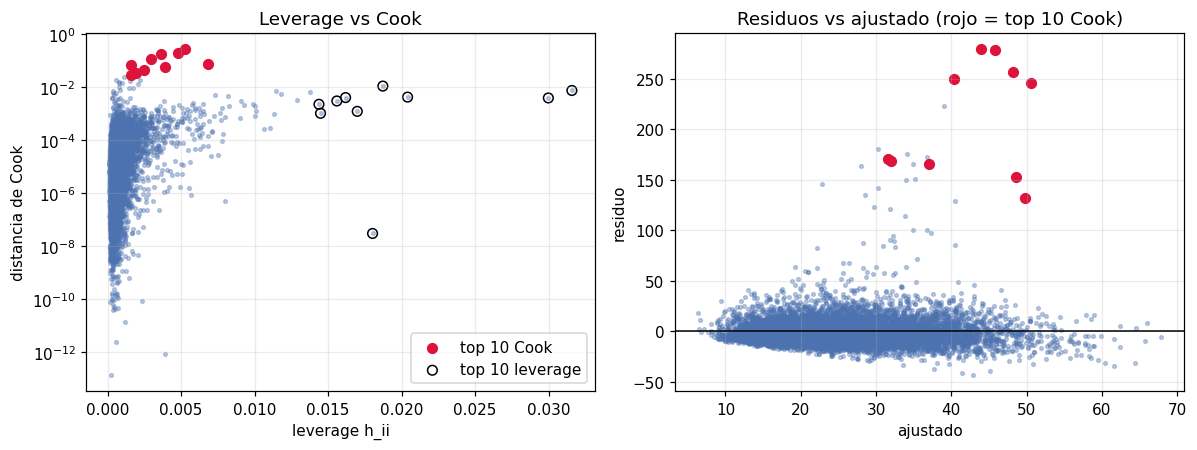

In [15]:
from scipy.stats import spearmanr
print(f"Spearman(leverage, Cook) en todos los datos: {spearmanr(h_all, cook)[0]:.3f}")
print(f"Umbral Cook 4/n = {4/len(cook):.5f} -> obs. por encima: {(cook > 4/len(cook)).sum()}")
print(f"Máximo Cook = {cook.max():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(h_all, cook, s=6, alpha=.35, color="#4c72b0")
ax[0].scatter(top_cook.leverage, top_cook.cook, s=40, color="crimson", label="top 10 Cook")
ax[0].scatter(top_lev.leverage, top_lev.cook, s=40, facecolors="none", edgecolors="black", label="top 10 leverage")
ax[0].set(xlabel="leverage h_ii", ylabel="distancia de Cook", yscale="log", title="Leverage vs Cook"); ax[0].legend()

ax[1].scatter(m_gases["fit"], e, s=6, alpha=.35, color="#4c72b0")
ax[1].scatter(m_gases["fit"][top_cook.index], e[top_cook.index], s=40, color="crimson")
ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="ajustado", ylabel="residuo", title="Residuos vs ajustado (rojo = top 10 Cook)")
plt.tight_layout(); plt.show()

### Reajuste sin los 10 más influyentes (por Cook)

In [16]:
d_full = m_gases["data"]
keep = np.ones(len(d_full), dtype=bool)
keep[top_cook.index.values] = False

m_sin = ols(d_full[GASES].values[keep], d_full["PM2.5"].values[keep])

keep_l = np.ones(len(d_full), dtype=bool)
keep_l[top_lev.index.values] = False
m_sin_lev = ols(d_full[GASES].values[keep_l], d_full["PM2.5"].values[keep_l])

nombres = ["Intercepto"] + GASES
comp = pd.DataFrame({
    "completo": m_gases["beta"],
    "sin top10 Cook": m_sin["beta"],
    "sin top10 leverage": m_sin_lev["beta"],
}, index=nombres)
comp["Δ% (Cook)"] = 100 * (comp["sin top10 Cook"] - comp["completo"]) / comp["completo"].abs()
display(comp.round(4))

resumen = pd.DataFrame({
    "n": [m_gases["n"], m_sin["n"], m_sin_lev["n"]],
    "R²": [m_gases["r2"], m_sin["r2"], m_sin_lev["r2"]],
    "s² (var. residual)": [m_gases["s2"], m_sin["s2"], m_sin_lev["s2"]],
}, index=["completo", "sin top10 Cook", "sin top10 leverage"])
display(resumen.round(4))

,completo,sin top10 Cook,sin top10 leverage,Δ% (Cook)
Intercepto,1.2363,1.3371,1.1632,8.1581
CO,13.2980,8.5379,13.5228,-35.7954
NO,-0.5073,-0.3795,-0.4966,25.1807
NO2,-0.1988,-0.0119,-0.1882,94.0345
NOX,0.4554,0.3544,0.4411,-22.1830
O3,0.1741,0.1838,0.1734,5.5755
SO2,0.2124,0.2117,0.2293,-0.3497


,n,R²,s² (var. residual)
completo,9247,0.2665,222.3841
sin top10 Cook,9237,0.3031,170.2373
sin top10 leverage,9237,0.2673,222.2861


**Conclusión de (f).**: en estos datos los 10 más influyentes (Cook) **no** coinciden con los 10 de mayor leverage (0 de 10 en común; Spearman global ≈ 0.39).

- Los **de mayor leverage** son lecturas extremas en los predictores (p. ej. NO ≈ 400 ppb en UAX o SO2 > 120 en TLA/MON) pero con PM2.5 normal, así que sus residuos son moderados y su Cook es pequeño (< 0.011).
- Los **de mayor Cook** son las horas de la madrugada del 1-ene-2026 en SAC (PM2.5 de 180–320 µg/m³ con gases normales): leverage bajo pero residuos enormes. Es el pico de PM2.5 de Año Nuevo, un episodio que los gases no explican.
- Al reajustar sin esos 10 puntos de Cook, R² sube de 0.267 a 0.303, la varianza residual baja de 222 a 170 y los coeficientes de CO, NO, NO2 y NOX cambian fuertemente (NO2 prácticamente se anula). Quitar los 10 de mayor leverage casi no cambia nada.
- Conviene tratar con cuidado esos puntos (evento puntual, no error de medición) y recordar que NO, NO2 y NOX son casi colineales, lo que hace inestables sus coeficientes.